# Optimal Investment Portfolio using MPT (Modern Portfolio Theory)

### What Each Strategy Optimizes for:

Equal Weight- simplicity (no constraints)

Inverse Vol- risk diversification (s.t. min/max weight bounds)

Min Variance- lowest portfolio variance (return not considered)

Target Return: hit specific return with minimal risk (may fail if target return is unfeasible)

Target Volatility: max return subject to risk level (may fail if volatility is unfeasible)

Max Sharpe: best risk-adjusted return, uses sharpe score (lies on the efficient frontier)

In [4]:
# =========================
# CHUNK 1 — CONFIGURATION
# =========================

CONFIG = {
    # --- Capital & horizon ---
    "initial_capital": 100_000,
    "start_date": "2022-07-01", # training on
    "end_date": "2025-07-25", # today

    # --- Universe ---
    "tickers": ["ARKF", "ARKG", "ARKK", "ARKQ", "ARKW", "SPY"],

    # --- Risk-free rate (annualized) ---
    "risk_free_rate_annual": 0.04,

    # --- Optimization choice ---
    # Options:
    #   "equal_weight"
    #   "inverse_vol"          (risk-parity style heuristic)
    #   "min_variance"
    #   "target_return"
    #   "target_volatility"
    #   "max_sharpe"           (picked off the efficient frontier)
    "strategy": "target_return",

    # --- Targets (used only by some strategies) ---
    "target_volatility_annual": 0.10,   # for "target_volatility"
    "target_return_annual": 0.50,       # for "target_return"

    # --- Constraints ---
    "allow_short": False,
    "min_weight": 0.00,                 # if allow_short=True you can set negative min_weight
    "max_weight": 0.50,                 # cap per asset to avoid concentration (set to 1.0 to disable)

    # --- Efficient frontier sampling ---
    "num_frontier_ports": 200,

    # --- Plotting flags ---
    "make_plots": True,
    "save_plots": False,
    "plot_dir": "figs",

    # --- Misc ---
    "annualization_factor": 252,        # daily data => 252
    "seed": 42,                         # for reproducibility (used where relevant)
}

=== Portfolio Builder ===
Dates: 2022-07-01 -> 2025-07-25
Strategy: target_return
Target return (annual): 50.00%


[*********************100%***********************]  6 of 6 completed


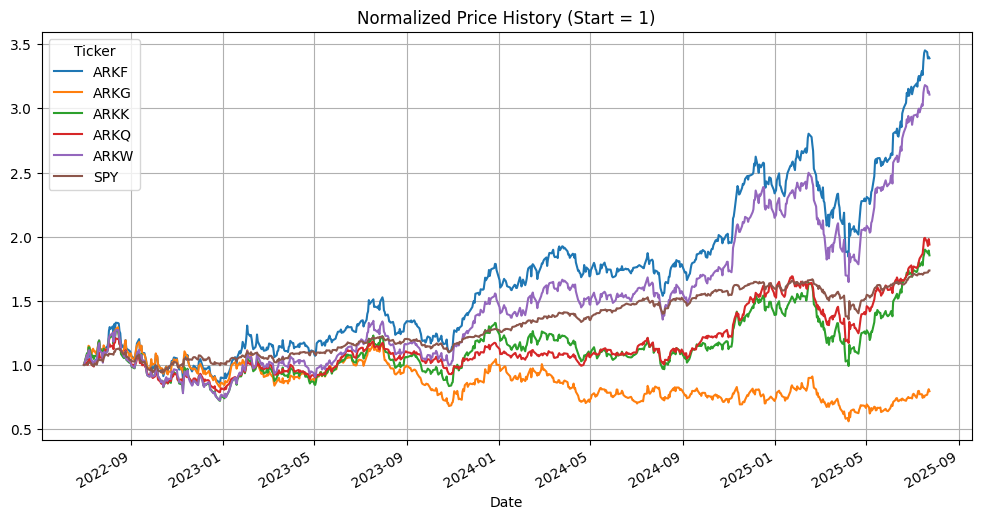

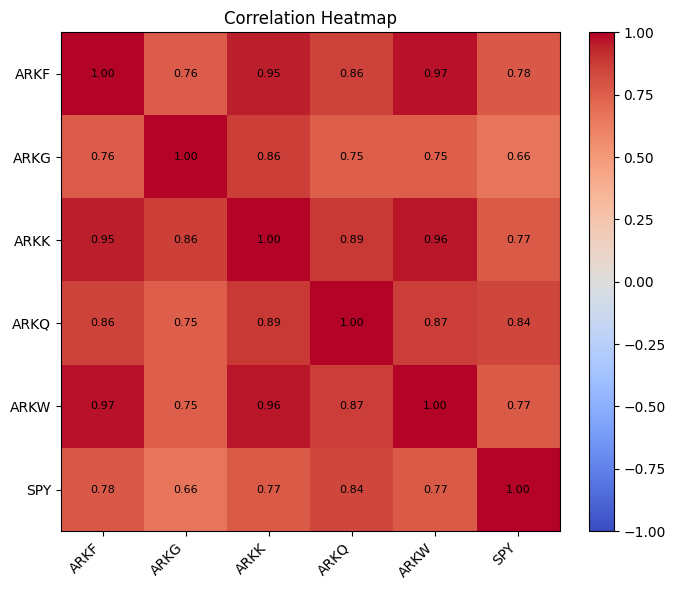

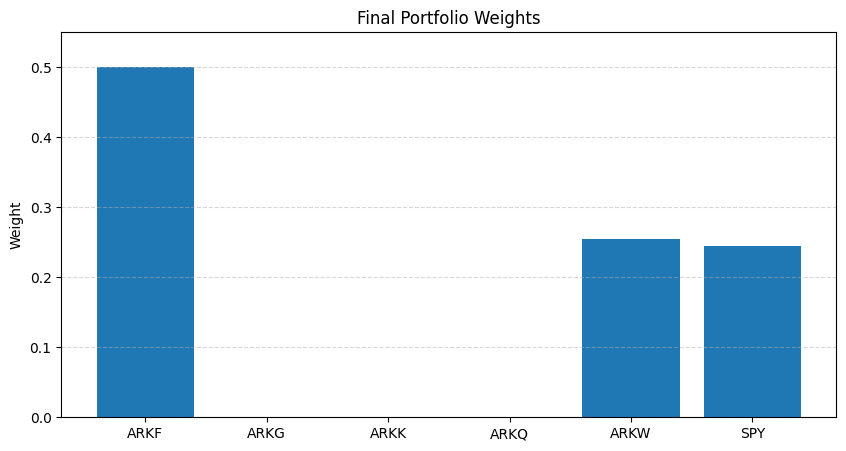


=== Final Portfolio ===
Ticker
ARKF    0.500
ARKG    0.000
ARKK    0.000
ARKQ    0.000
ARKW    0.255
SPY     0.245
dtype: float64

=== Metrics (annualized) ===
Expected Return: 50.00%
Volatility     : 33.89%
Sharpe Ratio   : 1.36  (rf=4.00%)

=== Capital Projection (1 year) ===
Initial capital        : $100,000
Projected 1Y value     : $150,000
Projected 1Y gain      : $50,000


In [5]:
# =========================
# CHUNK 2 — ENGINE
# =========================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import cvxpy as cp

# -------------------------
# Helpers
# -------------------------
def ann_factor(cfg):
    return cfg["annualization_factor"]

def to_annual_return(daily_mean, cfg):
    return (1 + daily_mean) ** ann_factor(cfg) - 1

def to_annual_vol(daily_vol, cfg):
    return daily_vol * np.sqrt(ann_factor(cfg))

def risk_free_daily(cfg):
    return (1 + cfg["risk_free_rate_annual"]) ** (1 / ann_factor(cfg)) - 1

def sharpe_ratio(ann_ret, ann_vol, rf_ann):
    if ann_vol == 0:
        return np.nan
    return (ann_ret - rf_ann) / ann_vol

def ensure_dir(path):
    if not os.path.exists(path):
        os.makedirs(path)

def as_1d(x):
    return np.asarray(x).ravel()

def quad_form(w, cov):
    w = as_1d(w)
    cov = np.asarray(cov)
    return float(w @ cov @ w)

def port_ret(mean_returns, w):
    return float(as_1d(mean_returns).T @ as_1d(w))

# -------------------------
# Data / stats
# -------------------------
def load_data(cfg):
    prices = yf.download(cfg["tickers"],
                         start=cfg["start_date"],
                         end=cfg["end_date"],
                         auto_adjust=True)["Close"].dropna(how="all")
    returns = prices.pct_change().dropna()
    return prices, returns

def compute_stats(returns):
    mean_returns = returns.mean()        # daily mean
    cov_matrix = returns.cov()
    vols = returns.std()
    return mean_returns, cov_matrix, vols

# -------------------------
# Plotting routines
# -------------------------
def plot_price_history(prices, cfg):
    if not cfg["make_plots"]:
        return
    normed = prices / prices.iloc[0]
    normed.plot(figsize=(12, 6), title="Normalized Price History (Start = 1)")
    plt.grid(True)
    if cfg["save_plots"]:
        ensure_dir(cfg["plot_dir"])
        plt.savefig(os.path.join(cfg["plot_dir"], "price_history.png"), dpi=200, bbox_inches="tight")
    plt.show()

def plot_corr_heatmap(returns, cfg):
    if not cfg["make_plots"]:
        return
    corr = returns.corr()
    plt.figure(figsize=(8, 6))
    im = plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
    plt.colorbar(im, fraction=0.046, pad=0.04)
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha='right')
    plt.yticks(range(len(corr.index)), corr.index)
    plt.title("Correlation Heatmap")
    for i in range(len(corr.columns)):
        for j in range(len(corr.index)):
            plt.text(j, i, f"{corr.iloc[i, j]:.2f}",
                     ha="center", va="center", color="black", fontsize=8)
    if cfg["save_plots"]:
        ensure_dir(cfg["plot_dir"])
        plt.savefig(os.path.join(cfg["plot_dir"], "correlation_heatmap.png"), dpi=200, bbox_inches="tight")
    plt.tight_layout()
    plt.show()

def plot_frontier_and_choice(frontier_risks, frontier_returns, chosen_risk, chosen_ret, cfg):
    if not cfg["make_plots"]:
        return
    if frontier_risks is None or len(frontier_risks) == 0:
        return
    plt.figure(figsize=(12, 6))
    plt.plot(frontier_risks, frontier_returns, label="Efficient Frontier", lw=2)
    if chosen_risk is not None and chosen_ret is not None:
        plt.scatter(chosen_risk, chosen_ret, c="red", s=180, marker="*", label="Chosen Portfolio")
    plt.xlabel("Annualized Volatility")
    plt.ylabel("Annualized Expected Return")
    plt.title("Efficient Frontier & Chosen Portfolio")
    plt.grid(True)
    plt.legend()
    if cfg["save_plots"]:
        ensure_dir(cfg["plot_dir"])
        plt.savefig(os.path.join(cfg["plot_dir"], "efficient_frontier.png"), dpi=200, bbox_inches="tight")
    plt.show()

def plot_allocations(weights, tickers, cfg, title="Final Portfolio Weights"):
    if not cfg["make_plots"]:
        return
    plt.figure(figsize=(10, 5))
    plt.bar(tickers, weights)
    plt.title(title)
    plt.ylabel("Weight")
    plt.ylim(0, max(0.35, float(np.max(weights)) + 0.05))
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    if cfg["save_plots"]:
        ensure_dir(cfg["plot_dir"])
        plt.savefig(os.path.join(cfg["plot_dir"], "weights.png"), dpi=200, bbox_inches="tight")
    plt.show()

# -------------------------
# Optimization primitives
# -------------------------
def _solve_and_return_weights(prob, w, name):
    try:
        prob.solve(warm_start=True)
    except Exception as e:
        raise ValueError(f"{name} optimization failed to solve: {e}")
    if w.value is None:
        raise ValueError(f"{name} optimization returned no solution (status: {prob.status})")
    return as_1d(w.value)

def optimize_min_variance(mean_returns, cov_matrix, cfg):
    n = len(mean_returns)
    w = cp.Variable(n)
    objective = cp.Minimize(cp.quad_form(w, cov_matrix.values))
    constraints = [cp.sum(w) == 1]
    if not cfg["allow_short"]:
        constraints.append(w >= cfg["min_weight"])
    if cfg["max_weight"] is not None and cfg["max_weight"] < 1.0:
        constraints.append(w <= cfg["max_weight"])
    prob = cp.Problem(objective, constraints)
    return _solve_and_return_weights(prob, w, "min_variance")

def optimize_target_return(mean_returns, cov_matrix, cfg):
    n = len(mean_returns)
    w = cp.Variable(n)
    daily_target = (1 + cfg["target_return_annual"]) ** (1 / ann_factor(cfg)) - 1
    portfolio_ret = mean_returns.values @ w
    objective = cp.Minimize(cp.quad_form(w, cov_matrix.values))
    constraints = [
        cp.sum(w) == 1,
        portfolio_ret >= daily_target
    ]
    if not cfg["allow_short"]:
        constraints.append(w >= cfg["min_weight"])
    if cfg["max_weight"] is not None and cfg["max_weight"] < 1.0:
        constraints.append(w <= cfg["max_weight"])
    prob = cp.Problem(objective, constraints)
    return _solve_and_return_weights(prob, w, "target_return")

def optimize_target_vol(mean_returns, cov_matrix, cfg):
    n = len(mean_returns)
    w = cp.Variable(n)
    daily_target_vol = cfg["target_volatility_annual"] / np.sqrt(ann_factor(cfg))
    portfolio_var = cp.quad_form(w, cov_matrix.values)
    objective = cp.Maximize(mean_returns.values @ w - risk_free_daily(cfg))
    constraints = [
        cp.sum(w) == 1,
        portfolio_var <= daily_target_vol ** 2
    ]
    if not cfg["allow_short"]:
        constraints.append(w >= cfg["min_weight"])
    if cfg["max_weight"] is not None and cfg["max_weight"] < 1.0:
        constraints.append(w <= cfg["max_weight"])
    prob = cp.Problem(objective, constraints)
    return _solve_and_return_weights(prob, w, "target_volatility")

def efficient_frontier(mean_returns, cov_matrix, cfg):
    """
    Build the frontier by sweeping target daily returns between min and max of sample means.
    """
    rets = mean_returns.values
    cov = cov_matrix.values

    min_r, max_r = rets.min(), rets.max()
    targets = np.linspace(min_r, max_r, cfg["num_frontier_ports"])

    risks_annual = []
    rets_annual = []
    weights_list = []

    for t in targets:
        n = len(rets)
        w = cp.Variable(n)
        portfolio_ret = rets @ w
        portfolio_var = cp.quad_form(w, cov)
        constraints = [cp.sum(w) == 1, portfolio_ret >= t]
        if not cfg["allow_short"]:
            constraints.append(w >= cfg["min_weight"])
        if cfg["max_weight"] is not None and cfg["max_weight"] < 1.0:
            constraints.append(w <= cfg["max_weight"])

        prob = cp.Problem(cp.Minimize(portfolio_var), constraints)
        try:
            prob.solve(warm_start=True)
        except Exception:
            continue

        if w.value is None:
            continue

        w_val = as_1d(w.value)
        # Daily stats
        daily_ret = port_ret(rets, w_val)
        daily_vol = np.sqrt(quad_form(w_val, cov))
        # Annualize
        rets_annual.append(to_annual_return(daily_ret, cfg))
        risks_annual.append(to_annual_vol(daily_vol, cfg))
        weights_list.append(w_val)

    return np.array(risks_annual), np.array(rets_annual), weights_list

def pick_max_sharpe_from_frontier(frontier_risks, frontier_returns, weights_list, cfg):
    rf = cfg["risk_free_rate_annual"]
    sharpes = [(r - rf) / v if v > 0 else np.nan for r, v in zip(frontier_returns, frontier_risks)]
    idx = int(np.nanargmax(sharpes))
    return weights_list[idx], frontier_risks[idx], frontier_returns[idx], sharpes[idx]

# -------------------------
# Higher-level strategy wrapper
# -------------------------
def choose_portfolio(mean_returns, cov_matrix, vols, cfg):
    tickers = mean_returns.index.tolist()
    n = len(tickers)

    frontier_risks = frontier_returns = weights_list = None
    chosen_ann_risk = chosen_ann_return = chosen_sharpe = None

    if cfg["strategy"] == "equal_weight":
        w = np.ones(n) / n

    elif cfg["strategy"] == "inverse_vol":
        inv = 1.0 / vols.values
        w = inv / inv.sum()
        # cap weights if max_weight < 1.0
        if cfg["max_weight"] is not None and cfg["max_weight"] < 1.0:
            # simple projection back to the feasible set (not strictly convex-correct)
            w = np.minimum(w, cfg["max_weight"])
            w = np.maximum(w, cfg["min_weight"])
            w = w / w.sum()

    elif cfg["strategy"] == "min_variance":
        w = optimize_min_variance(mean_returns, cov_matrix, cfg)

    elif cfg["strategy"] == "target_return":
        w = optimize_target_return(mean_returns, cov_matrix, cfg)

    elif cfg["strategy"] == "target_volatility":
        w = optimize_target_vol(mean_returns, cov_matrix, cfg)

    elif cfg["strategy"] == "max_sharpe":
        # Build a frontier and pick the best Sharpe on it
        frontier_risks, frontier_returns, weights_list = efficient_frontier(mean_returns, cov_matrix, cfg)
        if len(frontier_risks) == 0:
            raise ValueError("Efficient frontier failed to compute any feasible portfolios.")
        w, chosen_ann_risk, chosen_ann_return, chosen_sharpe = pick_max_sharpe_from_frontier(
            frontier_risks, frontier_returns, weights_list, cfg
        )
    else:
        raise ValueError(f"Unknown strategy: {cfg['strategy']}")

    # Compute final stats for chosen weights
    daily_mean_ret = port_ret(mean_returns.values, w)
    daily_vol = np.sqrt(quad_form(w, cov_matrix.values))

    ann_ret = to_annual_return(daily_mean_ret, cfg)
    ann_vol = to_annual_vol(daily_vol, cfg)
    sr = sharpe_ratio(ann_ret, ann_vol, cfg["risk_free_rate_annual"])

    # If we came from frontier with 'max_sharpe', reuse the computed numbers (they should match)
    if cfg["strategy"] == "max_sharpe" and chosen_ann_risk is not None:
        ann_vol = chosen_ann_risk
        ann_ret = chosen_ann_return
        sr = chosen_sharpe

    return w, ann_ret, ann_vol, sr, frontier_risks, frontier_returns, weights_list

# -------------------------
# Main
# -------------------------
def main(cfg):
    print("=== Portfolio Builder ===")
    print(f"Dates: {cfg['start_date']} -> {cfg['end_date']}")
    print(f"Strategy: {cfg['strategy']}")
    if cfg["strategy"] == "target_volatility":
        print(f"Target volatility (annual): {cfg['target_volatility_annual']:.2%}")
    if cfg["strategy"] == "target_return":
        print(f"Target return (annual): {cfg['target_return_annual']:.2%}")
    print("Downloading data...")

    prices, returns = load_data(cfg)
    plot_price_history(prices, cfg)
    plot_corr_heatmap(returns, cfg)

    mean_returns, cov_matrix, vols = compute_stats(returns)

    (weights,
     ann_ret,
     ann_vol,
     ann_sharpe,
     frontier_risks,
     frontier_returns,
     weights_list) = choose_portfolio(mean_returns, cov_matrix, vols, cfg)

    # Plot efficient frontier if we computed it, and show the chosen point
    plot_frontier_and_choice(frontier_risks, frontier_returns, ann_vol, ann_ret, cfg)

    # Plot final allocation
    plot_allocations(weights, mean_returns.index.tolist(), cfg)

    # Project one-year growth on initial capital (simple expectation)
    projected_1y_value = cfg["initial_capital"] * (1 + ann_ret)

    print("\n=== Final Portfolio ===")
    print(pd.Series(weights, index=mean_returns.index).round(4))

    print("\n=== Metrics (annualized) ===")
    print(f"Expected Return: {ann_ret:.2%}")
    print(f"Volatility     : {ann_vol:.2%}")
    print(f"Sharpe Ratio   : {ann_sharpe:.2f}  (rf={cfg['risk_free_rate_annual']:.2%})")

    print("\n=== Capital Projection (1 year) ===")
    print(f"Initial capital        : ${cfg['initial_capital']:,.0f}")
    print(f"Projected 1Y value     : ${projected_1y_value:,.0f}")
    print(f"Projected 1Y gain      : ${projected_1y_value - cfg['initial_capital']:,.0f}")


if __name__ == "__main__":
    main(CONFIG)
